# Perceptron learning

Implement full epochs and stop when an epoch makes no updates. The earlier version updated only the first mistake per pass. Both are possible learning schedules; this version makes epoch and stopping semantics explicit.


In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'ml_fundamentals').exists():
    root = root.parent
if not (root / 'ml_fundamentals').exists():
    raise RuntimeError('Start Jupyter from the repository root')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt

from ml_fundamentals.linear import fit_perceptron
X=np.array([[-2,3],[0,1],[2,-1],[-2,1],[0,-1],[2,-3]],dtype=float)
y=np.array([1,1,1,-1,-1,-1])
w,b,updates=fit_perceptron(X,y,max_epochs=100)
print('Epochs:',len(updates),'Updates per epoch:',updates)
print('All training margins positive:',bool(np.all(y*(X@w+b)>0)))


Epochs: 2 Updates per epoch: [4, 0]
All training margins positive: True


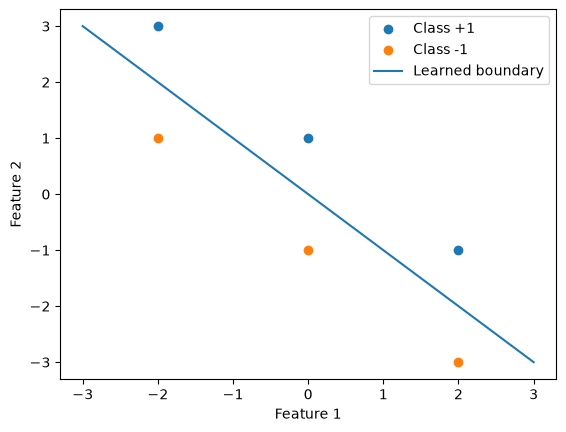

In [2]:
plt.scatter(X[y==1,0],X[y==1,1],label='Class +1')
plt.scatter(X[y==-1,0],X[y==-1,1],label='Class -1')
xx=np.linspace(-3,3,100)
if abs(w[1])>1e-12:plt.plot(xx,-(w[0]*xx+b)/w[1],label='Learned boundary')
elif abs(w[0])>1e-12:plt.axvline(-b/w[0],label='Learned boundary')
plt.xlabel('Feature 1');plt.ylabel('Feature 2');plt.legend();plt.show()


Zero training mistakes do not identify a unique or optimal separator. Nonseparable data can keep causing updates; the maximum epoch budget prevents an endless loop. Tests cover both cases.
